<a href="https://colab.research.google.com/github/kaushikpatriot/ML-Projects/blob/main/Linear_Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The objective of this colab is


*   Demonstrate training data and model components of linear regression model
*   Demonstrate how simple it is to implement ML components and algos

Let's import necessary libraries

In [ ]:
from IPython.display import display, Math, Latex #Imported for proper rendering of latex in Colab
import numpy as np

#Import for generating plots
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

##C1 - Training Data

###Quick Recap

1.   Training Data consists of features and labels that is real number
2.   Model or inference $y = Xw$



In [ ]:
def generate_data(n, w0, w1):
  # Create a dataset of 100 examples with a single feature and a label
  # For this construction, we use the following parameters
  X = 10*np.random.rand(n,)
  # obtain y = 4 + 3*X + noise. Noise is randomly sampled
  y = w0 + w1*X + np.random.rand(n,)
  return X, y

In [ ]:
X, y = generate_data(100,4,3)

Lets examine the shape of training data for sanity check

In [ ]:
print ('Shape of the training data feature matrix',X.shape)
print ('Shape of the label vectors', y.shape)

Shape of the training data feature matrix (100,)
Shape of the label vectors (100,)


Lets divide the dataset into training and test sets. 20% of the data is set aside for test

In [ ]:
def preprocess(X,y):
  from sklearn.model_selection import train_test_split
  X_train, X_test, y_train,  y_test = train_test_split(X,y,test_size = 0.20, random_state = 42)
  return X_train, X_test, y_train, y_test

#X_train, X_test, y_train,  y_test = preprocess(X,y)

Lets do a quick sanity check on the Training and Test data split

In [ ]:
print ('Shape of the training data feature matrix for training',X_train.shape)
print ('Shape of the training data feature matrix for testing', X_test.shape)
print ('Shape of the label data for training',y_train.shape)
print ('Shape of the label data for testing', y_test.shape)


Shape of the training data feature matrix for training (80,)
Shape of the training data feature matrix for testing (20,)
Shape of the label data for training (80,)
Shape of the label data for testing (20,)


Lets quickly check a few examples

In [ ]:
X_train[:5]

array([6.88334703, 0.37807782, 7.47722784, 5.55492959, 8.08933267])

In [ ]:
y_train[:5]

array([24.80887621,  5.30966338, 27.23675834, 21.39734474, 28.37222053])

Lets visualize the training set

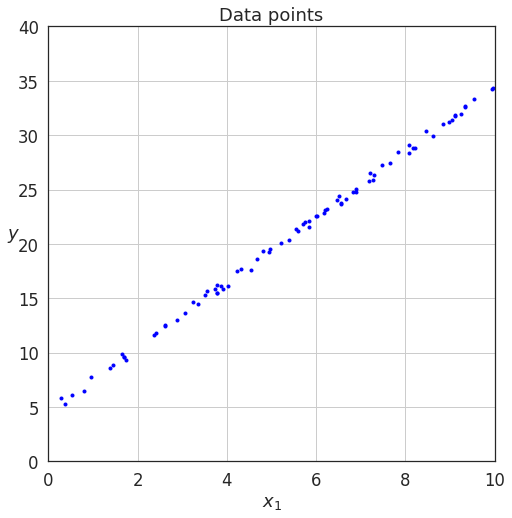

In [ ]:
sns.set_style("white")
f = plt.figure(figsize = (8,8))
sns.set_context ("notebook", font_scale = 1.5, rc={"lines.linewidth":2.5})

plt.plot(X_train,y_train,"b.")
plt.title("Data points")
plt.grid(True)
plt.xlabel("$x_1$", fontsize = 18)
plt.ylabel("$y$", rotation = 0, fontsize = 18)
plt.axis([0,10,0,40])

plt.show()

We have a training set consisting of a single feature so we will fit a simple linear regression model with one feature. Its form is $y = w_0 + w_1x_1$

As discussed, we add a special dummy feature $x_0$ and set it to 1. We create a helper function for that.

In [ ]:
def add_dummy_feature(x):
  ''' Adds a dummy feature to the dataset

  Args:
    x: Training Dataset

  Returns:
    Training dataset with the addition of the dummy feature
  '''
  #np.ones(x.shape(0)) creates a vector of 1s having the same rows as number of samples in dataset
  return np.column_stack((np.ones(x.shape[0]),x))

Lets write a test case to test this function
For that let's take two examples and three features.
The first feature vector is $x^{(1)}$ = [3 4 5]
The second feature vector is $x^{(2)}$ = [9 4 7]

To be completed


In [ ]:
import unittest

class TestAddDummyFeature(unittest.TestCase):
  def test_add_dummy_feature(self):
    #Test case function for add_dummy_feature
    train_matrix = np.array([[3,2,5],[9,4,7]])
    train_matrix_with_dummy_feature = add_dummy_feature(train_matrix)

    #Test the shape
    self.assertEqual(train_matrix_with_dummy_feature.shape,(2,4))

    # and contents
    np.testing.assert_array_equal(train_matrix_with_dummy_feature,np.array([[1,3,2,5],[1,9,4,7]]))

unittest.main(argv=[''], defaultTest='TestAddDummyFeature',verbosity=2, exit=False)


test_add_dummy_feature (__main__.TestAddDummyFeature) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.003s

OK


Let's preprocess the training set to add the dummy feature

In [ ]:
print ('Before adding the dummy feature:\n', X_train[:5])
print ('\n')

X_train = add_dummy_feature(X_train)

print ('After adding the dummy feature:\n', X_train[:5,:])

Before adding the dummy feature:
 [6.88334703 0.37807782 7.47722784 5.55492959 8.08933267]


After adding the dummy feature:
 [[1.         6.88334703]
 [1.         0.37807782]
 [1.         7.47722784]
 [1.         5.55492959]
 [1.         8.08933267]]


##C2 - Model

Implementation

The general vectorized form is as follows

$y_{n\times1} = X_{n\times(m+1)}w_{(m+1)\times1}$

where


*   n is number of examples in the dataset (train/test/validation)
*   m is the number of features
*   $X$ is a feature matrix contains (m+1) features for n examples
*   $w$ is a weight vector containing (m+1) weights one for each feature
*   $y$ is a label vector for n examples with shape $(n,)$









In [ ]:
def predict(X, w):
  '''
  Arg: X - Feature matrix of shape (n,m+1)
       w - weight vector (m+1,n)
  Return:
       y - the predicted label (n,)
  '''
  assert X.shape[-1] == w.shape[0] , 'X and w do not have compatible shapes'
  return X @ w


Test the Predict function as follows

In [ ]:
import unittest

class TestPredict(unittest.TestCase):

  def test_predict(self):
    #set up
    train_matrix = np.array([[1,3,2,5],[1,9,4,7]])
    weight_vector = np.array([1,1,1,1])
    expected_label_vector = np.array([11,21])

    #call
    predicted_label_vector = predict(train_matrix, weight_vector)

    #Test the shape
    self.assertEqual(predicted_label_vector.shape,(2,))

    #Test the contents
    np.testing.assert_array_equal(expected_label_vector, predicted_label_vector)

unittest.main(argv=[''], defaultTest = 'TestPredict', verbosity = 2, exit = False)


test_predict (__main__.TestPredict) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.002s

OK


##C3 - Loss

The objective of this Colab is to implement the loss function from scratch

###Quick Recap
1. Training Data containts features and the labels
2. Model or inference is $y = Xw$
3. Loss function $J(w) = 1/2(Xw-y)^T(Xw-y)$

where
* X is a feature matrix contain (m+1) features of n examples along rows
* w is a weight vector containing (m+1) weights one for each feature
* y is a label matrix containing labels for n examples in a vector of shape (n,)


In [ ]:
def loss(X,y,w):
  '''
  Args:
       X - Feature matrix
       y - label vector
       w - weight vector
  Returns:
       loss value for the given model
  '''
  e = (predict(X,w) - y)
  return (1/2)*(np.transpose(e) @ e)



In [ ]:
## Test the Loss function
import unittest

class TestLossFunction(unittest.TestCase):
  def test_loss_function(self):
    feature_matrix = np.array([[1,3,2,5],[1,9,4,7]])
    weight_vector = np.array([1,1,1,1])
    label_vector = np.array([6,11])
    expected_loss = np.array([62.5])


    #call
    actual_loss = loss(feature_matrix,label_vector,weight_vector)

    #asserts
    self.assertEqual(actual_loss.shape,())

    #contents
    np.testing.assert_array_equal(expected_loss,actual_loss)

unittest.main(argv=[''], defaultTest = 'TestLossFunction', verbosity = 2, exit = False)


test_loss_function (__main__.TestLossFunction) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.003s

OK


##C4 - Optimization

###Normal Equation Method

The weight vector is estimated by matrix multiplication of the pseudo inverse of the feature matrix with label vector

In [ ]:
def normal_equation(X,y):
  '''
  Arg:
      X - Feature matrix
      y - Label vector

  Returns
      w - the weight vector
  '''
  return np.linalg.pinv(X) @ y

We test this function by using data for which the weight vectors are already known to us

In [ ]:
import unittest

class TestNormalEquation(unittest.TestCase):
  def test_normal_eq(self):
    # set up
    feature_matrix = X_train
    label_vector = y_train
    expected_weight_vector = np.array([4.,3.])

    #call
    estimated_weight_vector = normal_equation(feature_matrix,label_vector)

    #Test shape
    self.assertEqual(estimated_weight_vector.shape,(2,))

    #Test content
    np.testing.assert_array_almost_equal(estimated_weight_vector,expected_weight_vector,decimal=0)

unittest.main(argv=[''],defaultTest = 'TestNormalEquation', verbosity = 2, exit = False)



test_normal_eq (__main__.TestNormalEquation) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.021s

OK


###Gradient Descent (GD)
GD is implemented as follows
* Randomly initialize $w$ to 0
* Iterate until convergence
  * Calculate partial derivative of loss w.r.t weight vector
  * Calculate new values of weights
  * Update weights to new values simultaneously

We use a number of epochs as a convergence criteria in this implementation


###Partial Derivative of Loss function
Lets first implement a function to calculate partial derivative of loss function, which is obtained with the following equation

$\frac {\partial J(w)}{\partial w } = X^T(Xw-y)$  

The multiplication of transpose of feature matrix with the difference of predicted and actual label vectors

In [ ]:
def calculate_gradient(X, y, w):
  '''
  Args:
      X - Feature matrix
      y - Label vector
      w - weight vectors
  Returns:
      A vector of gradients
  '''
  return np.transpose(X)@(predict(X,w) - y)

Testing the gradient function

In [ ]:
import unittest

class TestCalculateGradient(unittest.TestCase):
  def test_calculate_gradient(self):
    # set up
    feature_matrix = np.array([[1,3,2,5],[1,9,4,7]])
    weight_vector = np.array([1,1,1,1])
    label_vector = np.array([6,11])
    expected_grad = np.array([15,105,50,95])

    #call
    grad = calculate_gradient(feature_matrix, label_vector, weight_vector)

    #Test shape
    self.assertEqual(grad.shape,(4,))

    #Test content
    np.testing.assert_array_almost_equal(expected_grad,grad,decimal=0)

unittest.main(argv=[''],defaultTest='TestCalculateGradient',verbosity=2, exit=False)

test_calculate_gradient (__main__.TestCalculateGradient) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.003s

OK


##Weight Update
Weight update is done as follows

$w_{t+1} = w_t - lr\times gradient(w_t)$

In [ ]:
def update_weight(w,grad,lr):
  '''
  Args:
     w - weight vector
     grad - gradient of loss w.r.t w
     lr - learning rate
  Returns:
     Updated weight vector

  '''
  return (w - lr*grad)

In [ ]:
# Test the weight update function
import unittest
class TestUpdateWeights(unittest.TestCase):
  def test_update_weights(self):
    #set up
    weight_vector = np.array([1,1,1,1])
    grad_vector = np.array([15,105,50,95])
    lr = 0.001
    expected_w_new = np.array([0.985,0.895,0.95,0.905])

    #call
    w_new = update_weight(weight_vector,grad_vector,lr)

    #Test shape
    self.assertEqual(w_new.shape, (4,))

    # Test content
    np.testing.assert_array_almost_equal(expected_w_new,w_new,decimal=1)

unittest.main(argv=[''],defaultTest = 'TestUpdateWeights', verbosity = 2, exit = False)


test_update_weights (__main__.TestUpdateWeights) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.005s

OK


In [ ]:
#Estimates the parameters (w) of linear regression model through gradient descent
def gradient_descent(X:np.ndarray,y:np.ndarray,lr:float,num_epochs:int):
  '''
  Args:
      X: Feature matrix
      y: Label vector
      lr: learning rate
      num_epochs: Number of training steps
  Returns:
      Weight vector: Final weight vector
      Error vector across different iterations
      Weight vectors across different iterations
  '''
  w_all = [] # All parameters across iterations
  err_all = [] # All errors across iterations

  #Parameter vector initialised to zero
  w = np.zeros((X.shape[1]))

  #Gradient descent loop
  print()
  for i in np.arange(0,num_epochs):
    w_all.append(w)

    #Calculate the error due to the current weight vector
    err_all.append(loss(X,y,w))

    # Gradient Calculation
    dJdW = calculate_gradient(X,y,w)

    # Print stats every 100 iterations
    if i%100 == 0:
      print('Iteration #: %d, loss: %4.2f' %(i,err_all[-1]))

    # Weight vector update
    w = update_weight(w,dJdW,lr)

    #print('Gradient - ', dJdW)
    #print('Weight -', w)

  return w, err_all, w_all




In [ ]:
# Test the Optimization Calc
import unittest
class TestGradientDescent(unittest.TestCase):
  def test_gradient_descent(self):
    #set up
    feature_matrix = X_train
    label_vector = y_train
    expected_weights = np.array([4.,3.])

    #Call
    w, err_all, w_all = gradient_descent(feature_matrix, label_vector, lr=0.0001,num_epochs = 2000)

    #Test the shape
    self.assertEqual(w.shape,(2,))

    # Test contents
    np.testing.assert_array_almost_equal(expected_weights,w,decimal=0)

unittest.main(argv=[''],defaultTest = 'TestGradientDescent', verbosity=2,exit=False)



test_gradient_descent (__main__.TestGradientDescent) ... 


Iteration #: 0, loss: 19724.12
Iteration #: 100, loss: 93.86
Iteration #: 200, loss: 70.59
Iteration #: 300, loss: 53.28
Iteration #: 400, loss: 40.42
Iteration #: 500, loss: 30.85
Iteration #: 600, loss: 23.74
Iteration #: 700, loss: 18.45
Iteration #: 800, loss: 14.52
Iteration #: 900, loss: 11.59
Iteration #: 1000, loss: 9.42
Iteration #: 1100, loss: 7.80
Iteration #: 1200, loss: 6.60
Iteration #: 1300, loss: 5.70
Iteration #: 1400, loss: 5.04
Iteration #: 1500, loss: 4.55
Iteration #: 1600, loss: 4.18
Iteration #: 1700, loss: 3.90
Iteration #: 1800, loss: 3.70
Iteration #: 1900, loss: 3.55


ok

----------------------------------------------------------------------
Ran 1 test in 0.036s

OK


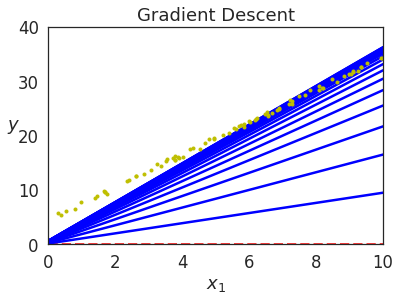

In [ ]:
#Plot model trajectory
X_b = np.c_[np.ones((X.shape[0],1)),X] #add x0 = 1 to each instance
X_new = np.array([[0],[10]])
X_new_b = np.c_[np.ones((2,1)),X_new] #add x0 = 1 to each instance

for j in range(0, len(w_all)):
  if j%10 !=0: continue
  y_hat = predict(X_new_b, w_all[j])
  style = "b-" if j > 0 else "r--"
  plt.plot (X_new_b[:,1], y_hat,style)

plt.plot (X_train[:,1], y_train, "y.")
plt.xlabel('$x_1$', fontsize=18)
plt.ylabel('$y$', rotation = 0, fontsize=18)
plt.title('Gradient Descent', fontsize=18)
plt.axis([0,10,0,40])
plt.show()

Let's plot the learning curves

In [ ]:
def plot_learning_curve(err_all):
  plt.plot(err_all)
  plt.xlabel('iteration #')
  plt.ylabel('Loss: $J(\mathbf{w})$')


Iteration #: 0, loss: 19724.12
Iteration #: 100, loss: 168.39
Iteration #: 200, loss: 118.25
Iteration #: 300, loss: 114.79
Iteration #: 400, loss: 111.53
Iteration #: 500, loss: 108.36
Iteration #: 600, loss: 105.29
Iteration #: 700, loss: 102.31
Iteration #: 800, loss: 99.42
Iteration #: 900, loss: 96.61
Iteration #: 1000, loss: 93.88
Iteration #: 1100, loss: 91.23
Iteration #: 1200, loss: 88.66
Iteration #: 1300, loss: 86.16
Iteration #: 1400, loss: 83.74
Iteration #: 1500, loss: 81.39
Iteration #: 1600, loss: 79.10
Iteration #: 1700, loss: 76.89
Iteration #: 1800, loss: 74.73
Iteration #: 1900, loss: 72.64


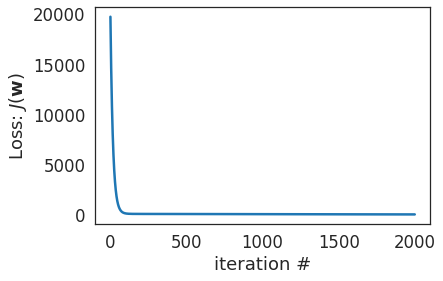

In [ ]:
w, err_all, w_all = gradient_descent(X_train,y_train,lr=0.00001,num_epochs=2000)
plot_learning_curve(err_all)

##C4 - Optimization - Variations in GD (Mini Batch GD and Stochastic GD)

In [ ]:
#Learning rate is gradually adjusted for MBGD and SGD
t0, t1 = 200, 10000
def learning_schedule(t):
  return t0 / (t + t1)

In [ ]:
#MBGD function
def mini_batch_gd(X:np.ndarray, y:np.ndarray,num_iters:int,minibatch_size:int):
  w_all = []
  err_all = []

  w = np.zeros((X.shape[1])) #initialise w to 0
  t = 0

  for epoch in range(num_iters):
    shuffled_indices = np.random.permutation(X.shape[0])
    X_shuffled = X[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for i in range (0,X.shape[0],minibatch_size):
      t +=1
      xi = X_shuffled[i:i+minibatch_size]
      yi = y_shuffled[i:i+minibatch_size]
      err_all.append(loss(xi,yi,w))

      gradients = 2/minibatch_size * calculate_gradient(xi,yi,w) # gradient scaled for MBGD & SGD
      lr = learning_schedule(t)

      w = update_weight(w, gradients, lr)
      w_all.append(w)

  return w, err_all, w_all


In [ ]:
import unittest
class TestMiniBatchGradientDescent(unittest.TestCase):
  def test_minibatch_gd(self):
    # set up
    feature_matrix = X_train
    label_vector = y_train
    expected_weights = np.array([4.,3.])

    #call
    w, err_all, w_all = mini_batch_gd(feature_matrix, label_vector,200, 8)

    #Test shape
    self.assertEqual(w.shape,(2,))

    #Test content
    np.testing.assert_array_almost_equal(expected_weights,w,decimal=0)

unittest.main(argv=[''], defaultTest = 'TestMiniBatchGradientDescent', verbosity = 2, exit = False)

test_minibatch_gd (__main__.TestMiniBatchGradientDescent) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.043s

OK


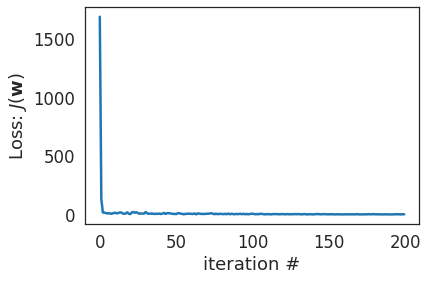

In [ ]:
w, err_all, w_all = mini_batch_gd(X_train, y_train, 20, 8)
plot_learning_curve(err_all)

##Stochastic Gradient Descent

In [ ]:
#SGD function
def sgd(X:np.ndarray, y:np.ndarray,num_epochs:int):
  w_all = []
  err_all = []

  w = np.zeros((X.shape[1])) #initialise w to 0
  t = 0

  for epoch in range(num_epochs):
    for i in range(X.shape[0]):
      random_index = np.random.randint(X.shape[0])
      xi = X[random_index:random_index+1]
      yi = y[random_index:random_index+1]
      err_all.append(loss(xi,yi,w))

      gradients = 2 * calculate_gradient(xi,yi,w) # gradient scaled for MBGD & SGD
      lr = learning_schedule(epoch * X.shape[0] + i)

      w = update_weight(w, gradients, lr)
      w_all.append(w)

  return w, err_all, w_all


In [ ]:
import unittest
class TestSGD(unittest.TestCase):
  def test_minibatch_gd(self):
    # set up
    feature_matrix = X_train
    label_vector = y_train
    expected_weights = np.array([4.,3.])

    #call
    w, err_all, w_all = sgd(feature_matrix, label_vector,20)

    #Test shape
    self.assertEqual(w.shape,(2,))

    #Test content
    np.testing.assert_array_almost_equal(expected_weights,w,decimal=0)

unittest.main(argv=[''], defaultTest = 'TestSGD', verbosity = 2, exit = False)

test_minibatch_gd (__main__.TestSGD) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.036s

OK


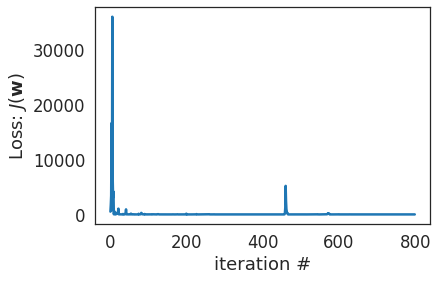

In [ ]:
w, err_all, w_all = sgd(X_train, y_train, 10)
plot_learning_curve(err_all)

In [ ]:
#Root Mean Squared Error
def rmse(X:np.ndarray, y:np.ndarray):
  return np.sqrt((2/X.shape[0])*loss(X,y,w))

###Consolidated Linear Regression Class

In [ ]:
class LinReg(object):
  def __init__(self):
    self.t0 = 200
    self.t1 = 100000


  def predict(self, X: np.ndarray) -> np.ndarray:
    '''
    Arg: X - Feature matrix of shape (n,m+1)
        w - weight vector (m+1,n)
    Return:
        y - the predicted label (n,)
    '''
    assert X.shape[-1] == self.w.shape[0] , 'X and w do not have compatible shapes'
    return X @ self.w

  def loss(self, X: np.ndarray,y: np.ndarray) -> float:
    '''
    Args:
        X - Feature matrix
        y - label vector
        w - weight vector
    Returns:
        loss value for the given model
    '''
    e = (self.predict(X) - y)
    return (1/2)*(np.transpose(e) @ e)

  def rmse(self, X:np.ndarray, y:np.ndarray) -> float:
    '''
    Args:
        X - Feature
        y - Label
    Returns:
        Loss
    '''
    return np.sqrt((2/X.shape[0])*self.loss(X,y))

  #Normal Equation Method
  def fit(self, X: np.ndarray,y: np.ndarray) -> np.ndarray:
    '''
    Arg:
        X - Feature matrix
        y - Label vector

    Returns
        w - the weight vector
    '''
    self.w = np.linalg.pinv(X) @ y
    return self.w

  # Gradient Batch
  def calculate_gradient(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
    '''
    Args:
        X - Feature matrix
        y - Label vector
        w - weight vectors
    Returns:
        A vector of gradients
    '''
    return np.transpose(X)@(self.predict(X) - y)

  def update_weight(self, grad: np.ndarray,lr: float) -> np.ndarray:
    '''
    Args:
      w - weight vector
      grad - gradient of loss w.r.t w
      lr - learning rate
    Returns:
      Updated weight vector

    '''
    return (self.w - lr*grad)

  def learning_schedule (self,t):
    return self.t0/(t + self.t1)

  def gd(self, X:np.ndarray,y:np.ndarray,lr:float,num_epochs:int) -> np.ndarray:
    '''
    Args:
        X: Feature matrix
        y: Label vector
        lr: learning rate
        num_epochs: Number of training steps
    Returns:
        Weight vector: Final weight vector
        Error vector across different iterations
        Weight vectors across different iterations
    '''
    self.w_all = [] # All parameters across iterations
    self.err_all = [] # All errors across iterations

    #Parameter vector initialised to zero
    self.w = np.zeros((X.shape[1]))

    #Gradient descent loop
    print()
    for i in np.arange(0,num_epochs):
      self.w_all.append(self.w)

      #Calculate the error due to the current weight vector
      self.err_all.append(self.loss(X,y))

      # Gradient Calculation
      dJdW = self.calculate_gradient(X,y)

      # Print stats every 100 iterations
      if i%100 == 0:
        print('Iteration #: %d, loss: %4.2f' %(i,self.err_all[-1]))

      # Weight vector update
      self.w = self.update_weight(dJdW,lr)

      #print('Gradient - ', dJdW)
      #print('Weight -', w)

    return self.w

  #MBGD function
  def mbgd(self, X:np.ndarray, y:np.ndarray,num_iters:int,minibatch_size:int) -> np.ndarray:
    self.w_all = []
    self.err_all = []

    self.w = np.zeros((X.shape[1])) #initialise w to 0
    t = 0

    for epoch in range(num_iters):
      shuffled_indices = np.random.permutation(X.shape[0])
      X_shuffled = X[shuffled_indices]
      y_shuffled = y[shuffled_indices]
      for i in range (0,X.shape[0],minibatch_size):
        t +=1
        xi = X_shuffled[i:i+minibatch_size]
        yi = y_shuffled[i:i+minibatch_size]
        self.err_all.append(self.loss(xi,yi))

        gradients = 2/minibatch_size * self.calculate_gradient(xi,yi) # gradient scaled for MBGD & SGD
        lr = self.learning_schedule(t)

        self.w = self.update_weight(gradients, lr)
        self.w_all.append(self.w)

    return self.w

  #SGD function
  def sgd(self, X:np.ndarray, y:np.ndarray,num_epochs:int):
    self.w_all = []
    self.err_all = []

    self.w = np.zeros((X.shape[1])) #initialise w to 0
    t = 0

    for epoch in range(num_epochs):
      for i in range(X.shape[0]):
        random_index = np.random.randint(X.shape[0])
        xi = X[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        self.err_all.append(self.loss(xi,yi))

        gradients = 2 * self.calculate_gradient(xi,yi) # gradient scaled for MBGD & SGD
        lr = self.learning_schedule(epoch * X.shape[0] + i)

        self.w = self.update_weight(gradients, lr)
        self.w_all.append(self.w)

    return self.w


In [ ]:
X, y = generate_data(100,4,3)
X_train, X_test, y_train,y_test = preprocess(X,y)
X_train = add_dummy_feature(X_train)
X_test = add_dummy_feature(X_test)

In [ ]:
lin_reg = LinReg()
lin_reg.fit(X_train,y_train)
print('Weight vector from normal equation: ', lin_reg.w)

Weight vector from normal equation:  [4.41919187 3.00791334]


In [ ]:
lin_reg = LinReg()
lin_reg.gd(X_train,y_train,0.0001,2000)
print('Weight vector from Gradient: ', lin_reg.w)


Iteration #: 0, loss: 18407.18
Iteration #: 100, loss: 106.42
Iteration #: 200, loss: 72.43
Iteration #: 300, loss: 49.64
Iteration #: 400, loss: 34.35
Iteration #: 500, loss: 24.10
Iteration #: 600, loss: 17.23
Iteration #: 700, loss: 12.62
Iteration #: 800, loss: 9.53
Iteration #: 900, loss: 7.45
Iteration #: 1000, loss: 6.06
Iteration #: 1100, loss: 5.13
Iteration #: 1200, loss: 4.51
Iteration #: 1300, loss: 4.09
Iteration #: 1400, loss: 3.81
Iteration #: 1500, loss: 3.62
Iteration #: 1600, loss: 3.49
Iteration #: 1700, loss: 3.41
Iteration #: 1800, loss: 3.35
Iteration #: 1900, loss: 3.31
Weight vector from Gradient:  [4.34777088 3.01857578]
